<a href="https://colab.research.google.com/github/oliviapang/DS_3001_Assignments/blob/main/Assignment_2/2_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1

In [ ]:
'''
1. Regression predicts values for continuous, quantitative variables while classification predicts values for discrete, categorical variables.
2. A confusion matrix cross-tabulates true labels with predicted labels. It allows us to see how accurate the model was with predicting values. We can see where it
made mistakes and what the entries were mislabeled as.
3. Accuracy is the proportion of correctly predicted cases. Accuracy may not be sufficient to evaluate a model's performance as it will not show systematic biases.
4. Root mean squared error quantifies the distance from the true values to the predicted values, and it is weighted by sample size.
5. Overfitting is when the model sees/tries to fit patterns that aren't actually there/are just noise. Underfitting is when a model fails to capture patterns that are
present in the data.
6. Splitting the data into a train set and a test set helps improve the model because it allows us to evaluate the model's performance on data it hasn't seen before, as
this is how will be when the model is deployed. Choosing k based on the model's accuracy with the test set ensures the model is not overfitting.
7. Predictions (hard classification) target the boundaries between classes and attempt to draw a clear line. They provide clear, simple responses. However, they can be
less accurate and are not nuanced, potentially over simplifying things. Probability distributions have higher accuracy and may handle overlapping classes better. However,
they are more computationally expensive and are more complex to implement and interpret.
'''

Question 2

In [22]:
! git clone https://github.com/oliviapang/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

,mine_type
count,338.000000
mean,2.952663
std,1.419703
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


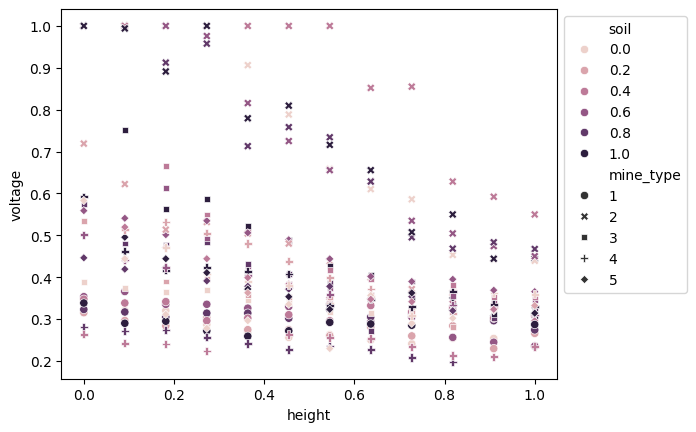

In [23]:
# 1
df = pd.read_csv('/content/data/land_mines.csv')
df
#sns.kdeplot(x = df['height'], hue = df['mine_type'])
plot = sns.scatterplot(data = df, x = 'height', y = 'voltage', hue = 'soil', style = 'mine_type')
sns.move_legend(plot, "upper left", bbox_to_anchor=(1, 1))
df['mine_type'].describe()

In [24]:
# 2
from sklearn.model_selection import train_test_split

y = df['mine_type'] # Set out outcome/target
x = ['soil', 'voltage', 'height'] # List of control variables
u = df.loc[:, x] # Set our covariates/features

u_train, u_test, y_train, y_test = train_test_split(u,y, # Feature and target variables
                                                    test_size=.5, # Split the sample
                                                    random_state=100) # For replication purposes


Test accuracy for 3 neighbors is 0.3727810650887574; train accuracy for 3 neighbors is 0.6153846153846154
Test accuracy for 5 neighbors is 0.3609467455621302; train accuracy for 5 neighbors is 0.5621301775147929
Test accuracy for 7 neighbors is 0.3254437869822485; train accuracy for 7 neighbors is 0.5502958579881657
Test accuracy for 9 neighbors is 0.33727810650887574; train accuracy for 9 neighbors is 0.5088757396449705
Test accuracy for 11 neighbors is 0.3668639053254438; train accuracy for 11 neighbors is 0.5088757396449705
Test accuracy for 13 neighbors is 0.39644970414201186; train accuracy for 13 neighbors is 0.5266272189349113
Test accuracy for 15 neighbors is 0.34911242603550297; train accuracy for 15 neighbors is 0.48520710059171596
Test accuracy for 17 neighbors is 0.35502958579881655; train accuracy for 17 neighbors is 0.4378698224852071
Test accuracy for 19 neighbors is 0.31952662721893493; train accuracy for 19 neighbors is 0.4319526627218935
Test accuracy for 21 neighbors

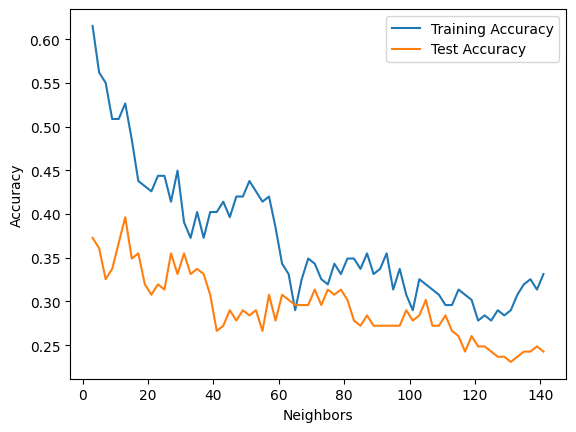

In [25]:
# 3
from sklearn.neighbors import KNeighborsClassifier

k_grid = np.array([ (2*k+3) for k in range(0,70)]) # Odd number grid
test_accuracies = []
train_accuracies = []
for k in k_grid: # For each candidate value of k...
    model = KNeighborsClassifier(n_neighbors = k) # Create a model instance
    model = model.fit(u_train,y_train) # Fit the model
    y_hat = model.predict(u_test) # Predict values
    test_acc = model.score(u_test,y_test) # Compute test accuracy
    train_acc = model.score(u_train,y_train) # Compute trainin accuracy
    print( f'Test accuracy for {k} neighbors is {test_acc}; train accuracy for {k} neighbors is {train_acc}')
    test_accuracies.append(test_acc) # Save test results
    train_accuracies.append(train_acc) # Save training results

sns.lineplot(x=k_grid,y=train_accuracies,label='Training Accuracy').set(xlabel='Neighbors',ylabel='Accuracy')
sns.lineplot(x=k_grid,y=test_accuracies,label='Test Accuracy')
plt.show()
# from above, it appears that 3 is the best number for k

k = 3
model = KNeighborsClassifier(n_neighbors = k) # Create a model instance
model = model.fit(u_train,y_train) # Fit the model, training set
y_hat = model.predict(u_test) # Predictions, test set



In [26]:
# 4
print( pd.crosstab(y_test, y_hat)) # Confusion matrix
model.score(u_test,y_test) # Test accuracy
# The model had an accuracy of 37.3%. It was good at predicting type 2 mines, ok at predicting type 1, and kind of bad at
# predicting types 3 to 5

col_0       1   2   3  4   5
mine_type                   
1          27   0   6  3   2
2           0  22   6  2   5
3          10   2   7  3  11
4          16   2  11  4   2
5          12   1   9  3   3


0.3727810650887574

In [ ]:
# 5
'''
I would tell them to take the prediction with a (several) grain of salt. The model had a test accuracy of less than 50%, so
while it does make correct guesses, a lot of them are also wrong. It would perhaps be useful to take the predicted mine type but
then conduct other tests to get more concrete verification of the type.
'''

Question 3

In [27]:
# 1
df = pd.read_csv('/content/data/USA_cars_datasets.csv')

drop = ['Unnamed: 0', 'brand', 'model', 'title_status', 'color', 'vin', 'lot', 'state', 'country', 'condition']
data = df.drop(columns = drop)
print(data.shape)
data.head()
#data['mileage'].unique()

(2499, 3)


,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


In [30]:
# 2
def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

data['year'] = minmax(data['year'])
data['mileage'] = minmax(data['mileage'])
data.head()

,price,year,mileage
0,6300,0.744681,0.269287
1,2899,0.808511,0.187194
2,5350,0.957447,0.038892
3,25000,0.872340,0.063016
4,27700,0.957447,0.006537


In [31]:
# 3
from sklearn.model_selection import train_test_split

y = data['price'] # Set out outcome/target
x = ['year', 'mileage'] # List of control variables
u = data.loc[:, x] # Set our covariates/features

u_train, u_test, y_train, y_test = train_test_split(u,y, # Feature and target variables
                                                    test_size=.2, # Split the sample
                                                    random_state=100) # For replication purposes

MSE for 3 neighbors is 126446573.21822222


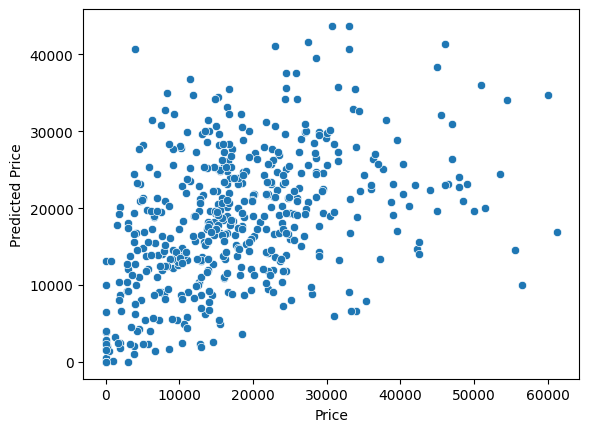

MSE for 10 neighbors is 110802185.58681999


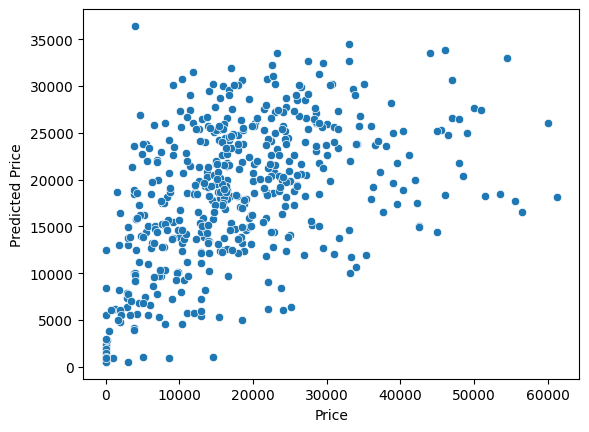

MSE for 25 neighbors is 103170457.848608


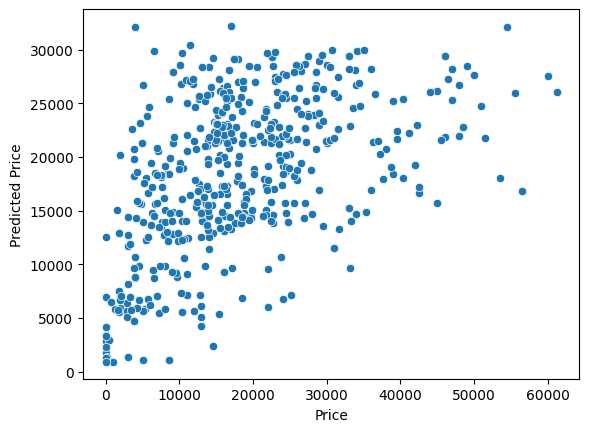

MSE for 50 neighbors is 99695443.96419598


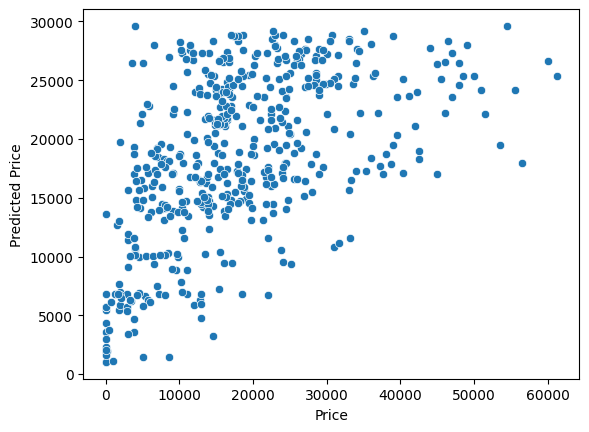

MSE for 100 neighbors is 98271058.96092059


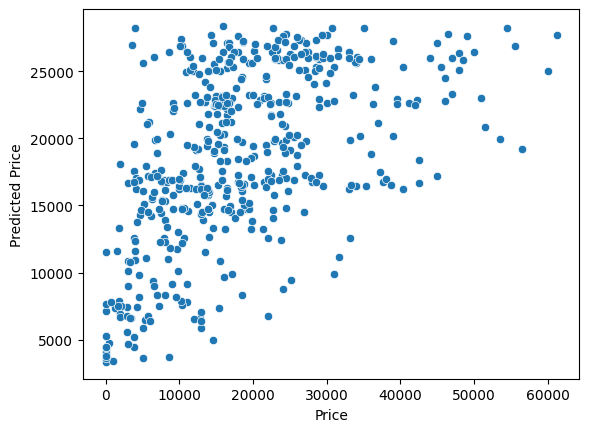

MSE for 300 neighbors is 100477298.914212


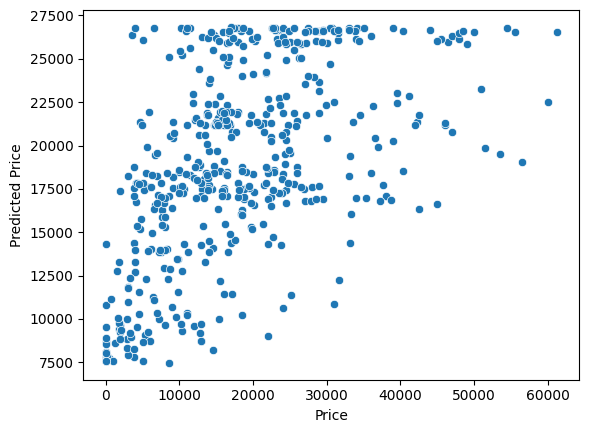

In [41]:
# 4
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

def mse(y_test,y_hat):
    mse = np.sum( (y_test - y_hat) ** 2 )/len(y_test)
    return mse

k_grid = np.array([3, 10, 25, 50, 100, 300]) # Odd number grid

mses = [] # List to save MSEs
for k in k_grid:
    model = KNeighborsRegressor(n_neighbors = k) # Create a model instance
    model = model.fit(u_train,y_train) # Fit the model
    y_hat = model.predict(u_test) # Predict values
    mses.append(mse(y_test, y_hat) ) # Compute and store MSE
    print( f'MSE for {k} neighbors is {mses[-1]}')
    plt.figure()
    plot = sns.scatterplot(x=y_test, y=y_hat)
    plot.set_xlabel('Price')
    plot.set_ylabel('Predicted Price')
    plt.show()

# As k increases, the MSE decreases through k = 100. At k = 300, the MSE increases again.

In [ ]:
# 5
# The optimal k would be 100 based on above.

In [ ]:
# 6
'''
In the plot for k = 3, the data are pretty spread out. If most points were predicted correctly, they would fall on a diagonal line.
However, in this plot they're very spread out, likely because the model is underfitting and not taken enough patterns into account.
In the k = 10 to k = 100 plots, the data pull closer to the diagonal, meaning more prices are being correctly predicted. In the
k = 300 plot, a lot of cars are being incorrectly priced very high, meaning the model may be overfitting the data and erroneously
predicting these high prices.

Question 6

In [281]:
# 1
df = pd.read_csv('/content/data/airbnb_hw.csv')
df = df.loc[:, ['Review Scores Rating', 'Price', 'Beds']]
x = df['Price'].str.replace(',','')
df['Price'] = pd.to_numeric(x, errors = 'coerce')
df['Beds'] = pd.to_numeric(df["Beds"], errors="coerce")

In [282]:
# 2
missing = df.loc[df["Review Scores Rating"].isnull()].copy()
missing = missing.dropna(subset=["Beds"])

In [283]:
# 3
df = df.dropna(axis=0, how='any')

MSE for 3 neighbors is 97.28638179214711
MSE for 5 neighbors is 88.74877684829302
MSE for 7 neighbors is 86.6568955413954
MSE for 9 neighbors is 85.63627000276334
MSE for 11 neighbors is 83.42290580978843
MSE for 13 neighbors is 82.48819444351541
MSE for 15 neighbors is 81.32632451578868
MSE for 17 neighbors is 81.19349781380281
MSE for 19 neighbors is 80.66712532011276
MSE for 21 neighbors is 81.48877620231904
MSE for 23 neighbors is 81.4394779480179
MSE for 25 neighbors is 81.0153387293692
MSE for 27 neighbors is 80.07867373658148
MSE for 29 neighbors is 79.32729761168984
MSE for 31 neighbors is 79.11877817754745
MSE for 33 neighbors is 78.97034451559352
MSE for 35 neighbors is 78.85661020546586
MSE for 37 neighbors is 78.57692300705176
MSE for 39 neighbors is 78.19093427563139
MSE for 41 neighbors is 77.96988297207434
MSE for 43 neighbors is 78.06065789880739
MSE for 45 neighbors is 77.95174271415135
MSE for 47 neighbors is 77.9803911955766
MSE for 49 neighbors is 78.0386861190835
M

<Axes: >

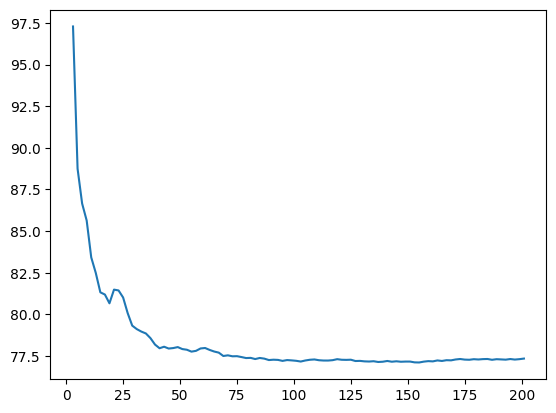

In [269]:
# 4
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

y = df['Review Scores Rating'] # Set out outcome/target
x = ['Price', 'Beds'] # List of control variables
u = df.loc[:, x] # Set our covariates/features

def mse(y_test,y_hat):
    mse = np.sum( (y_test - y_hat) ** 2 )/len(y_test)
    return mse

u_train, u_test, y_train, y_test = train_test_split(u,y, # Feature and target variables
                                                    test_size=.2, # Split the sample
                                                    random_state=100) # For replication purposes
k_grid = np.array([ (2*k+3) for k in range(0,100)])
mses = [] # List to save MSEs
for k in k_grid:
    model = KNeighborsRegressor(n_neighbors = k) # Create a model instance
    model = model.fit(u_train,y_train) # Fit the model
    y_hat = model.predict(u_test) # Predict values
    mses.append( mse(y_test, y_hat) ) # Compute and store MSE
    print( f'MSE for {k} neighbors is {mses[-1]}')
sns.lineplot(x=k_grid, y=mses) # Plot MSE

# MSE is low around k = 101

In [289]:
# 5
k = 101

y = missing['Review Scores Rating'] # Set out outcome/target
x = ['Price', 'Beds'] # List of control variables
u = missing.loc[:, x] # Set our covariates/features

y_train = df['Review Scores Rating']
u_train = df.loc[:, x]

model = KNeighborsClassifier(n_neighbors = k) # Create a model instance
model = model.fit(u_train,y_train) # Fit the model
y_hat = model.predict(u) # Hard prediction

y_hat


array([100., 100., 100., ..., 100., 100., 100.])

<Axes: ylabel='Density'>

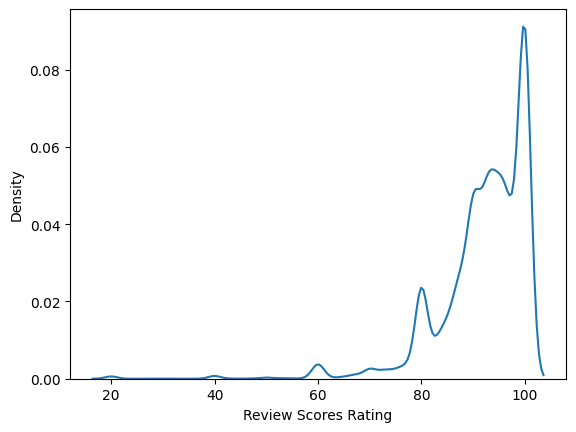

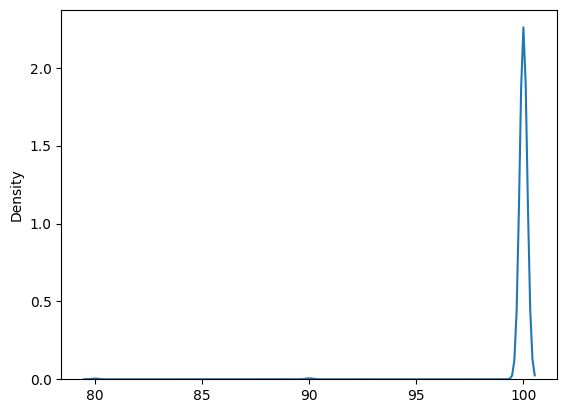

In [288]:
# 6
plt.figure()
sns.kdeplot(df['Review Scores Rating'])
plt.figure()
sns.kdeplot(y_hat)
# The model predicted scores of 100 or near 100 for all of the airbnbs with missing ratings. I'm not sure if this was a mistake
# or if I did something wrong. There is a spike in ratings of 100 in the data that is present, so I guess it may be possible that
# the model would predict mostly 100s.